# Comparison of HOG-based Classical Classifiers and CNN Models for Diabetic Retinopathy Diagnosis

**Experiment Notebook**  
Author: Yelizaveta Kabanova  
Date: 2025/2026

## Imports

In [2]:
# !pip install scikit-image


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import os
import pathlib
import random
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import itertools
import joblib
from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA, IncrementalPCA
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, 
                             cohen_kappa_score, classification_report, 
                             precision_score, recall_score, 
                             confusion_matrix, roc_curve, auc)

sns.set_style("darkgrid")
sns.set_theme(palette="muted")

## Configuration

In [ ]:
# ===============================
# Variables
# ===============================
# == path ==
DATA_DIR = pathlib.Path(r"C:\Users\eliza\Portfolio\blindness-detection")
EXPORT_DIR = DATA_DIR / "hog_svm_data"
RESULTS_PATH = EXPORT_DIR / "hog_results.csv" 

batch_size = 256
max_k = 256
n_components = 160

## Data Loading

In [ ]:
# ============================================================
# Load Datasets
# ============================================================
train_df = pd.read_csv(EXPORT_DIR / "train_B1.csv")
val_df = pd.read_csv(EXPORT_DIR / "val_B1.csv")

In [3]:
print(train_df.shape, val_df.shape)

(7220, 3) (1805, 3)


In [4]:
train_df.head()

,id_code,diagnosis,image_path
0,ca25745942b0_aug_490864,1,C:\Users\eliza\Portfolio\blindness-detection\t...
1,b9c7c5182075,0,C:\Users\eliza\Portfolio\blindness-detection\t...
2,879744b9dc65_aug_455844,2,C:\Users\eliza\Portfolio\blindness-detection\t...
3,a9a3225cf4b5,0,C:\Users\eliza\Portfolio\blindness-detection\t...
4,ca63fe4f4b52,1,C:\Users\eliza\Portfolio\blindness-detection\t...


## Feature Engineering (HOG)

### Sample Visualization

4833
Path: C:\Users\eliza\Portfolio\blindness-detection\train_images_bal_v2\681c3c115684.png
Label: 2


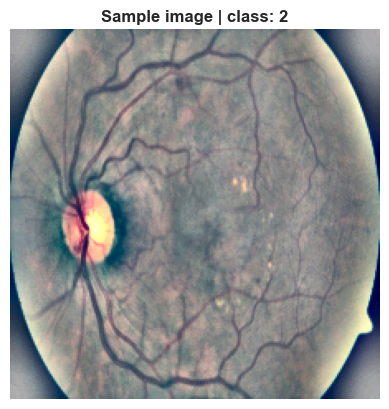

In [ ]:
# === Sample selection ===
sample_number = np.random.randint(0, train_df.shape[0])
print(sample_number)

sample_path = train_df.iloc[sample_number]["image_path"]
sample_label =  train_df.iloc[sample_number]["diagnosis"]

print("Path:", sample_path)
print("Label:", sample_label)

# === Load image ===
sample_img = cv2.imread(sample_path)
sample_img = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)

# === Plot ===
plt.figure()
plt.imshow(sample_img)
plt.title(f"Sample image | class: {sample_label}", fontsize=12, weight="bold")
plt.axis('off')
plt.show()

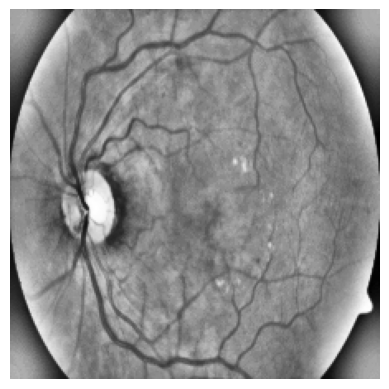

In [ ]:
# === Convert to grayscale ===
img_gray = cv2.cvtColor(sample_img, cv2.COLOR_RGB2GRAY)

plt.figure()
plt.imshow(img_gray, cmap='gray')
plt.title("Grayscale image", fontsize=12, weight="bold")
plt.axis('off')
plt.show()

### HOG Parameter Exploration

In [ ]:
# === HOG parameter grid ===
orientations_list = [9, 12]
pixels_per_cell_list = [(4, 4), (6,6), (8,8)]
cells_per_block_list = [(2, 2)]

param_combinations = list(itertools.product(
    orientations_list,
    pixels_per_cell_list,
    cells_per_block_list
))

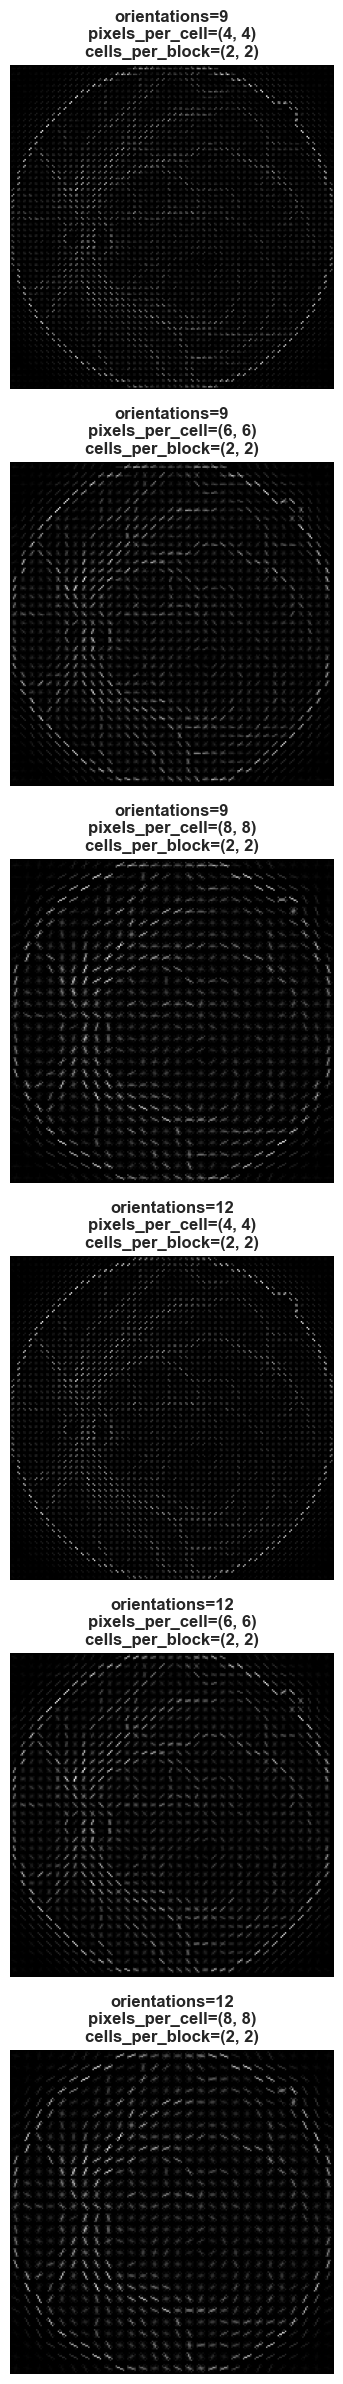

In [ ]:
# === Visualize different HOG configs ===
fig, axes = plt.subplots(len(param_combinations), 1, figsize=(4, len(param_combinations)*4))

if len(param_combinations) == 1:
    axes = [axes] 

for ax, (orientations, pixels_per_cell, cells_per_block) in zip(axes, param_combinations):
    hog_features, hog_image = hog(
        img_gray,
        orientations=orientations,
        pixels_per_cell=pixels_per_cell,
        cells_per_block=cells_per_block,
        block_norm="L2-Hys",
        visualize=True,
        feature_vector=True
    )
    
    hog_image = (hog_image - hog_image.min()) / (hog_image.max() - hog_image.min())
    
    ax.imshow(hog_image, cmap='gray')
    ax.set_title(
        f"orientations={orientations}\n"
        f"pixels_per_cell={pixels_per_cell}\n"
        f"cells_per_block={cells_per_block}",
        fontsize=11
    )    
    ax.axis('off')

plt.tight_layout()
plt.show()

**Best Parameters:**
- orientations=9
- pixels_per_cell=(6, 6)
- cells_per_block=(2, 2)

### Final HOG Configuration

In [ ]:
# === Final HOG parameters ===
hog_params = {
    "orientations": 9,
    "pixels_per_cell": (6, 6),
    "cells_per_block": (2, 2),
    "block_norm": "L2-Hys",
    "visualize": True,
    "feature_vector": True
}

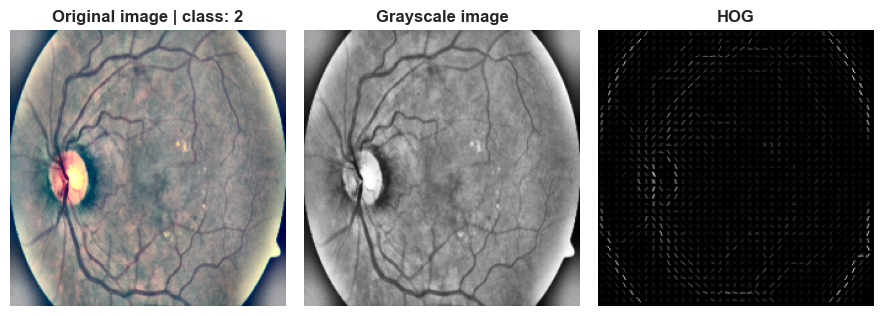

In [9]:
hog_features, hog_image = hog(img_gray, **hog_params)

hog_image = (hog_image - hog_image.min()) / (hog_image.max() - hog_image.min())

fig, ax = plt.subplots(1, 3,figsize=(9, 4))

ax[0].imshow(sample_img)
ax[0].set_title(f"Original image | class: {sample_label}", fontsize=12, weight="bold")
ax[0].axis('off')

ax[1].imshow(img_gray, cmap='gray')
ax[1].set_title("Grayscale image", fontsize=12, weight="bold")
ax[1].axis('off')

ax[2].imshow(hog_image, cmap='gray')
ax[2].set_title("HOG", fontsize=12, weight="bold")
ax[2].axis('off')     

plt.tight_layout()
plt.show()

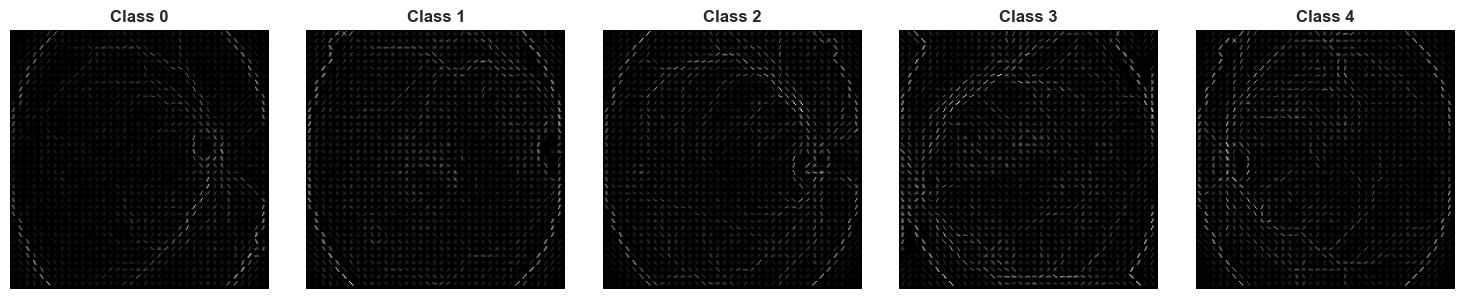

In [128]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, cls in enumerate([0, 1, 2, 3, 4]):
    sample = train_df[train_df["diagnosis"] == cls].iloc[5]
    img = cv2.imread(sample["image_path"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    hog_features, hog_img =hog(gray, **hog_params)
    hog_img = (hog_img - hog_img.min()) / (hog_img.max() - hog_img.min())

    axes[i].imshow(hog_img, cmap="gray")
    axes[i].set_title(f"Class {cls}", fontsize=12, weight="bold")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

### HOG feature extraction 

In [37]:
def extract_hog_features(df, img_column='image_path'):
    hog_features, hog_images = [], []
    for img_path in tqdm(df[img_column], total=len(df)):
        full_path = DATA_DIR / img_path
        # read img
        img = cv2.imread(str(full_path))
        if img is None:
            raise FileNotFoundError()
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        # hog
        hog_feat, hog_img = hog(img_gray, **hog_params)
        hog_img = (hog_img - hog_img.min()) / (hog_img.max() - hog_img.min())
        # save
        hog_features.append(hog_feat)
        hog_images.append(hog_img)
    return np.array(hog_features), np.array(hog_images)

In [ ]:
# === Extract HOG features ===
X_train, X_train_hog_imgs = extract_hog_features(train_df)
X_val, X_val_hog_imgs = extract_hog_features(val_df)

y_train = train_df['diagnosis'].values
y_val = val_df['diagnosis'].values

# === OPTIONAL: Load precomputed features (faster) ===
# X_train = np.load(EXPORT_DIR / "X_train_hog.npy")
# X_val = np.load(EXPORT_DIR / "X_val_hog.npy")
# y_train = np.load(EXPORT_DIR / "y_train.npy")
# y_val = np.load(EXPORT_DIR / "y_val.npy")

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)

In [ ]:
# === Save features ===
np.save(EXPORT_DIR / "X_train_hog.npy", X_train)
np.save(EXPORT_DIR / "X_train_hog_imgs.npy", X_train_hog_imgs)
np.save(EXPORT_DIR / "X_val_hog.npy", X_val)
np.save(EXPORT_DIR / "X_val_hog_imgs.npy", X_val_hog_imgs)
np.save(EXPORT_DIR / "y_train.npy", y_train)
np.save(EXPORT_DIR / "y_val.npy", y_val)
print('Success!')


Success!


## Data Preprocessing

### Feature Scaling

In [ ]:
# === Standard Scaler (incremental) ===
scaler = StandardScaler(with_mean=True, with_std=True)

for i in tqdm(range(0, X_train.shape[0], batch_size), desc="Fitting scaler"):
    batch = X_train[i:i+batch_size]
    scaler.partial_fit(batch)

Fitting scaler: 100%|██████████| 29/29 [00:05<00:00,  5.61it/s]


### Dimensionality Reduction (IncrementalPCA)

In [ ]:
# === Fit Incremental PCA ===
max_k = 256
ipca_full = IncrementalPCA(n_components=max_k)

for i in tqdm(range(0, X_train.shape[0], batch_size), desc="Fitting temp IPCA"):
    batch = scaler.transform(X_train[i:i+batch_size])
    ipca_full.partial_fit(batch)

Fitting temp IPCA:   0%|          | 0/29 [00:00<?, ?it/s]

Fitting temp IPCA: 100%|██████████| 29/29 [02:48<00:00,  5.82s/it]


In [71]:
def transform_with_ipca_k(X, scaler, ipca_full, k, batch_size=256):
    X_pca = []
    for i in range(0, X.shape[0], batch_size):
        batch = scaler.transform(X[i:i+batch_size])
        batch_pca = ipca_full.transform(batch)[:, :k]
        X_pca.append(batch_pca.astype(np.float32))
    return np.vstack(X_pca)

In [ ]:
# === PCA components search ===
components_list = [20, 40, 60, 80, 120, 160, 200, 256]
k_values_svm = []
k_values_rf = []
for k in components_list:
    X_train_k = transform_with_ipca_k(X_train, scaler, ipca_full, k)
    X_val_k   = transform_with_ipca_k(X_val, scaler, ipca_full, k)

    svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
    rf = RandomForestClassifier(
        n_estimators=300, 
        max_depth=None, 
        class_weight='balanced', 
        random_state=42, 
        n_jobs=-1
    )
    
    svm.fit(X_train_k, y_train)
    rf.fit(X_train_k, y_train)

    preds_svm = svm.predict(X_val_k)
    preds_rf = rf.predict(X_val_k)

    f1_svm = f1_score(y_val, preds_svm, average='macro')
    qwk_svm = cohen_kappa_score(y_val, preds_svm, weights="quadratic")

    f1_rf = f1_score(y_val, preds_rf, average='macro')
    qwk_rf = cohen_kappa_score(y_val, preds_rf, weights="quadratic")
    
    print(f"SVM | k={k}: F1={f1_svm:.4f}, QWK={qwk_svm:.4f}")
    print(f"RF  | k={k}: F1={f1_rf:.4f}, QWK={qwk_rf:.4f}")

    k_values_svm.append({'k': k, 'F1': f1_svm, 'QWK': qwk_svm})
    k_values_rf.append({'k': k, 'F1': f1_rf, 'QWK': qwk_rf})

===Results for SVM ===
k=20, F1=0.6311, QWK=0.6950
===Results for Random Forest ===
k=20, F1=0.7150, QWK=0.7442
===Results for SVM ===
k=40, F1=0.7296, QWK=0.7807
===Results for Random Forest ===
k=40, F1=0.7424, QWK=0.7811
===Results for SVM ===
k=60, F1=0.7628, QWK=0.8229
===Results for Random Forest ===
k=60, F1=0.7578, QWK=0.7934
===Results for SVM ===
k=80, F1=0.7801, QWK=0.8358
===Results for Random Forest ===
k=80, F1=0.7572, QWK=0.7907
===Results for SVM ===
k=120, F1=0.7889, QWK=0.8455
===Results for Random Forest ===
k=120, F1=0.7634, QWK=0.7793
===Results for SVM ===
k=160, F1=0.8021, QWK=0.8588
===Results for Random Forest ===
k=160, F1=0.7636, QWK=0.7970
===Results for SVM ===
k=200, F1=0.8000, QWK=0.8479
===Results for Random Forest ===
k=200, F1=0.7579, QWK=0.7727
===Results for SVM ===
k=256, F1=0.7950, QWK=0.8411
===Results for Random Forest ===
k=256, F1=0.7602, QWK=0.7784


In [ ]:
def visualize_pca_comparison(k_values, method):
    f1_scores = [item['F1'] for item in k_values]
    qwk_scores = [item['QWK'] for item in k_values]

    plt.figure(figsize=(6,4))
    plt.plot(components_list, f1_scores, marker = 'o', label="F1 Score", color='teal')
    plt.plot(components_list, qwk_scores, marker= '*', label='QWK', color='orange')
    
    plt.title(f'Metrics vs components ({method})', fontsize=12, weight="bold")
    plt.xlabel('Number of components')
    plt.ylabel('Value')
    plt.xticks(components_list)
    plt.grid(alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

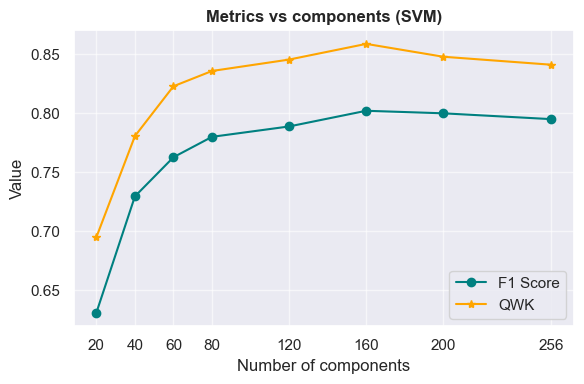

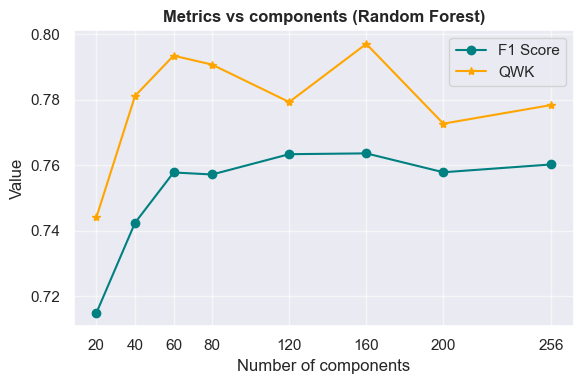

In [74]:
visualize_pca_comparison(k_values_svm, "SVM")
visualize_pca_comparison(k_values_rf, "Random Forest")

### Final Configuration

In [ ]:
# === SCALER (только для PCA-пайплайнов) === 
scaler = StandardScaler()

for i in tqdm(range(0, X_train.shape[0], batch_size), desc="Fitting scaler"):
    scaler.partial_fit(X_train[i:i+batch_size])

# === PCA === 
ipca = IncrementalPCA(n_components=n_components)

for i in tqdm(range(0, X_train.shape[0], batch_size), desc="Fitting IPCA"):
    batch_scaled = scaler.transform(X_train[i:i+batch_size])
    ipca.partial_fit(batch_scaled)

Fitting scaler: 100%|██████████| 29/29 [00:10<00:00,  2.64it/s]


In [ ]:
# === TRANSFORMING FUNCTION ===
def transform_with_ipca(X):
    X_out = []
    for i in tqdm(range(0, X.shape[0], batch_size), desc="Transforming PCA"):
        batch = scaler.transform(X[i:i+batch_size])
        X_out.append(ipca.transform(batch).astype(np.float32))
    return np.vstack(X_out)

In [ ]:
X_train_pca = transform_with_ipca(X_train)
X_val_pca = transform_with_ipca(X_val)

# === OPTIONAL: Load ===
# X_train_pca = np.load(EXPORT_DIR / "X_train_pca.npy")
# X_val_pca = np.load(EXPORT_DIR / "X_val_pca.npy")

print("X_train_pca:", X_train_pca.shape)  
print("X_val_pca:", X_val_pca.shape) 

Transforming PCA: 100%|██████████| 8/8 [00:02<00:00,  3.38it/s]

X_train_pca: (7220, 160)
X_val_pca: (1805, 160)


In [ ]:
# ==================
# SAVING
# ==================
np.save(EXPORT_DIR / "X_train_pca.npy", X_train_pca)
np.save(EXPORT_DIR / "X_val_pca.npy", X_val_pca)
print("PCA pipeline was saved!")

-- PCA pipeline was saved ---


## SVM

In [11]:
# =======================================
# SVM classifier with One-vs-One strategy (HOG + Scaler + PCA + SVM)
# ========================================
svm_ovo = OneVsOneClassifier(
    SVC(
        kernel='rbf',
        C=10,
        gamma='scale',
        class_weight='balanced',
        probability=True,
        random_state=42
    )
)

svm_ovo.fit(X_train_pca, y_train)
joblib.dump(svm_ovo, EXPORT_DIR / "svm_ovo_model1.pkl")

['C:\\Users\\eliza\\Portfolio\\blindness-detection\\hog_svm_data\\svm_ovo_model1.pkl']

In [6]:
svm_ovr = OneVsRestClassifier(
    SVC(
        kernel='rbf',
        C=10,
        gamma='scale',
        class_weight='balanced',
        probability=True,
        random_state=42
    )
)

svm_ovr.fit(X_train_pca, y_train)
joblib.dump(svm_ovr, EXPORT_DIR / "svm_ovr_model1.pkl")

['C:\\Users\\eliza\\Portfolio\\blindness-detection\\hog_svm_data\\svm_ovr_model1.pkl']

## Random Forest

### HOG + RF

In [25]:
# =======================================
# Random Forest (HOG + RF) 200 trees
# ========================================
rf_raw1 = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_raw1.fit(X_train, y_train)
joblib.dump(rf_raw1, EXPORT_DIR / "rf_raw_model1.pkl")

['C:\\Users\\eliza\\Portfolio\\blindness-detection\\hog_svm_data\\rf_raw_model1.pkl']

In [26]:
# =======================================
# Random Forest (HOG + RF) 300 trees
# ========================================
rf_raw2 = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_raw2.fit(X_train, y_train)
joblib.dump(rf_raw2, EXPORT_DIR / "rf_raw_model2.pkl")

['C:\\Users\\eliza\\Portfolio\\blindness-detection\\hog_svm_data\\rf_raw_model2.pkl']

In [27]:
# =======================================
# Random Forest (HOG + RF) 500 trees
# ========================================
rf_raw3 = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_raw3.fit(X_train, y_train)
joblib.dump(rf_raw3, EXPORT_DIR / "rf_raw_mode3.pkl")

['C:\\Users\\eliza\\Portfolio\\blindness-detection\\hog_svm_data\\rf_raw_mode3.pkl']

### HOG + PCA + RF

In [28]:
# =======================================
# Random Forest (HOG + PCA+ RF) 200 trees
# ========================================
rf_1 = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_1.fit(X_train_pca, y_train)
joblib.dump(rf_1, EXPORT_DIR / "rf_model1.pkl")

['C:\\Users\\eliza\\Portfolio\\blindness-detection\\hog_svm_data\\rf_model1.pkl']

In [29]:
# =======================================
# Random Forest (HOG + PCA+ RF) 300 trees
# ========================================
rf_2 = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_2.fit(X_train_pca, y_train)
joblib.dump(rf_2, EXPORT_DIR / "rf_model2.pkl")

['C:\\Users\\eliza\\Portfolio\\blindness-detection\\hog_svm_data\\rf_model2.pkl']

In [30]:
# =======================================
# Random Forest (HOG + PCA+ RF) 500 trees
# ========================================
rf_3 = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_3.fit(X_train_pca, y_train)
joblib.dump(rf_3, EXPORT_DIR / "rf_model3.pkl")

['C:\\Users\\eliza\\Portfolio\\blindness-detection\\hog_svm_data\\rf_model3.pkl']

## Evaluation

In [ ]:
# =============== 
# VISUALIZATION
# ===============
# ---------- Confusion Matrix ----------
def plot_confusion_matrix(cm, class_labels, model_name):
    plt.figure(figsize=(7,6))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title(f'Confusion Matrix\n{model_name}', fontsize=12, weight="bold")
    plt.tight_layout()
    plt.show()

# ---------- Roc Curve ----------
def plot_roc_curve(y_true_bin, y_scores, class_labels, model_name):
    plt.figure(figsize=(10,6))
    n_classes = y_true_bin.shape[1]
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
        roc_auc_val = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{class_labels[i]} (AUC = {roc_auc_val :.3f})")
        
    plt.plot([0,1],[0,1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve\n{model_name}", fontsize=12, weight="bold")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.5)
    plt.show()

# ---------- E-AUROC ----------
def plot_error_roc(confidence, y_true, y_pred, model_name):
    errors = (y_true != y_pred).astype(int)   # 1 если ошибка
    fpr, tpr, thresholds = roc_curve(errors, -confidence)  # минус, чтобы высокое confidence = меньше ошибок
    err_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, label=f"E-AUROC = {err_auc:.4f}", color='darkorange', lw=2)
    plt.plot([0,1], [0,1], 'k--', lw=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"Error Detection ROC\n{model_name}", fontsize=12, weight="bold")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()
    return err_auc

# ---------- Predictions ----------
def plot_predictions(val_set, hog_imgs, y_true, y_pred, model_name, class_labels, n_images=6):
    correct_idx = np.where(y_true == y_pred)[0]
    wrong_idx   = np.where(y_true != y_pred)[0]

    half = n_images // 2
    chosen_idx = []
    if len(correct_idx) > 0:
        chosen_idx.extend(np.random.choice(correct_idx, min(half, len(correct_idx)), replace=False))
    if len(wrong_idx) > 0:
        chosen_idx.extend(np.random.choice(wrong_idx, min(n_images-half, len(wrong_idx)), replace=False))
    chosen_idx = np.array(chosen_idx)

    plt.figure(figsize=(10, 10))
    for k, idx in enumerate(chosen_idx):
        plt.subplot(3, 3, k+1)
        plt.imshow(hog_imgs[idx], cmap='gray')
        plt.axis("off")

        color = "green" if y_true[idx]==y_pred[idx] else "red"
        plt.title(f"T:{class_labels[y_true[idx]]}\nP:{class_labels[y_pred[idx]]}",
                fontsize=10, color=color, weight="bold")

    plt.suptitle(f"Sample Predictions\n{model_name}", fontsize=12, weight="bold")
    plt.tight_layout()
    plt.show()

In [ ]:
# ======================
# CONFIDENCE
# ======================
def get_svm_confidence(model, model_name, val_set):
    probs = model.predict_proba(val_set)
    confidence = np.max(probs, axis=1)

    plt.figure(figsize=(6,4))
    plt.hist(confidence, bins=30)
    plt.title("Prediction Confidence (OvR SVM)", fontsize=12, weight="bold")
    plt.xlabel("Predicted Class Probability")
    plt.ylabel("Number of Samples")
    plt.grid(alpha=0.3)
    plt.show()
    
    return confidence

def get_rf_confidence(model, model_name, val_set):
    y_scores = model.predict_proba(val_set)
    confidence = np.max(y_scores, axis=1)
    
    plt.figure(figsize=(6,4))
    plt.hist(confidence, bins=30)
    plt.title(f"Prediction Confidence\n{model_name} (Probability)", fontsize=12, weight="bold")
    plt.xlabel("Predicted Class Probability")
    plt.ylabel("Number of Samples")
    plt.grid(alpha=0.3)
    plt.show()   
    return confidence 

In [ ]:
# ==============================
# UNCERTAINTY METRICS
# ==============================
def compute_aurc(confidence, correct):
    order = np.argsort(confidence)[::-1]
    correct_sorted = correct[order]
    risks = []
    for k in range(1, len(correct_sorted) + 1):
        risk = 1 - np.mean(correct_sorted[:k])
        risks.append(risk)
    return np.mean(risks)

def confidence_separation(confidence, y_true, y_pred):
    conf_correct = confidence[y_true == y_pred]
    conf_wrong   = confidence[y_true != y_pred]
    return float(np.mean(conf_correct) - np.mean(conf_wrong))

def error_detection_auc(confidence, y_true, y_pred):
    errors = (y_true != y_pred).astype(int)
    return float(roc_auc_score(errors, -confidence))

def evaluate_uncertainty(confidence, y_true, y_pred, model_name):
    correct = (y_true == y_pred).astype(int)

    aurc = compute_aurc(confidence, correct)
    sep  = confidence_separation(confidence, y_true, y_pred)
    err_auc = error_detection_auc(confidence, y_true, y_pred)
    mean_conf_correct = float(np.mean(confidence[y_true == y_pred]))
    mean_conf_wrong   = float(np.mean(confidence[y_true != y_pred]))

    return {
        "AURC": round(aurc,4),
        "E-AUROC": round(err_auc,4),
        "Mean Confidence": round(np.mean(confidence),4),        
        "Conf Separation": round(sep,4),
    }

In [ ]:
# =============================
# PREDICTION + EVALUATION
# =============================
def evaluate_model(val_set, y_true, model_name, model_path1, model_path2=None, hog_imgs=X_val_hog_imgs):
    model = joblib.load(model_path1)
    class_labels = np.unique(y_true)
    y_true_bin = label_binarize(y_true, classes=class_labels)

    # Prediction
    y_pred = model.predict(val_set)

    # Confidence
    if "RF" in model_name or (hasattr(model, "predict_proba") and not hasattr(model, "decision_function")):
        y_scores = model.predict_proba(val_set)  
        conf = get_rf_confidence(model, model_name, val_set)  
    elif "SVM" in model_name:
        model2 = joblib.load(model_path2)
        conf = get_svm_confidence(model2, model_name, val_set)  
        y_scores = model.decision_function(val_set)  
    else:
        raise ValueError("!ERROR: Unknown model type")

    # Calculate metrics
    qwk = cohen_kappa_score(y_true, y_pred, weights="quadratic") 
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    auc = roc_auc_score(y_true_bin, y_scores, average="macro")
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)

    # Plots 
    plot_confusion_matrix(cm_norm, class_labels, model_name)
    y_true_bin = label_binarize(y_true, classes=class_labels)
    plot_roc_curve(y_true_bin, y_scores, class_labels, model_name)
    plot_predictions(val_set, hog_imgs, y_true, y_pred, model_name, class_labels, n_images=6)

    plt.figure(figsize=(6,4))
    plt.hist(conf[y_pred == y_true], bins=30, alpha=0.6, label="Correct", color='green') # type: ignore
    plt.hist(conf[y_pred != y_true], bins=30, alpha=0.6, label="Wrong", color='red') # type: ignore
    plt.legend()
    plt.title(f" {model_name}\nConfidence: Correct vs Wrong Predictions", fontsize=12, weight="bold")
    plt.xlabel("Number of Samples")
    plt.ylabel("Confidence")
    plt.grid(alpha=0.3)
    plt.show()

    # Saving results
    unc_metrics = evaluate_uncertainty(conf, y_true, y_pred, model_name)
    plot_error_roc(conf, y_true, y_pred, model_name)
    
    row = {
        "Model": model_name,
        'QWK': round(qwk, 4),
        'Accuracy': round(acc, 4),
        'Precision (Macro)': round(precision, 4), # type: ignore
        'Recall (Macro)': round(recall, 4), # type: ignore
        'F1 Score (Macro)': round(f1, 4), # type: ignore
        'AUC (Macro)': round(auc, 4),
        **unc_metrics
    }
    # row = {k: (round(v, 2) if isinstance(v, (int, float)) else v) for k, v in row.items()}

    print("\n===== METRICS =====")
    print(f"\n|Classification Report|\n {classification_report(y_true, y_pred, digits=4)}")
    print("\n| " + "\n| ".join(f"{k}: {v:.4f}" if isinstance(v, (int, float)) else f"{k}: {v}" for k, v in row.items()))
    
    if os.path.exists(RESULTS_PATH):
        df = pd.read_csv(RESULTS_PATH)
    else:
        df = pd.DataFrame()
    if not df.empty and 'Model' in df.columns:
        mask = (df['Model'] == row['Model'])
    else:
        mask = pd.Series([False])
    if mask.any():
        df.loc[mask, :] = pd.DataFrame([row])
    else:
        df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
    df.to_csv(RESULTS_PATH, index=False)
    print(f"\n--- Results updated and saved to {RESULTS_PATH} ---")
    return row

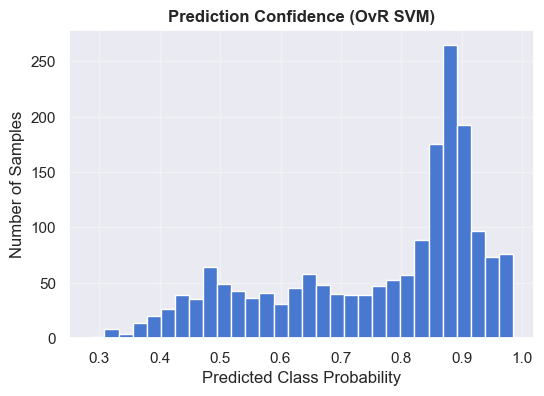

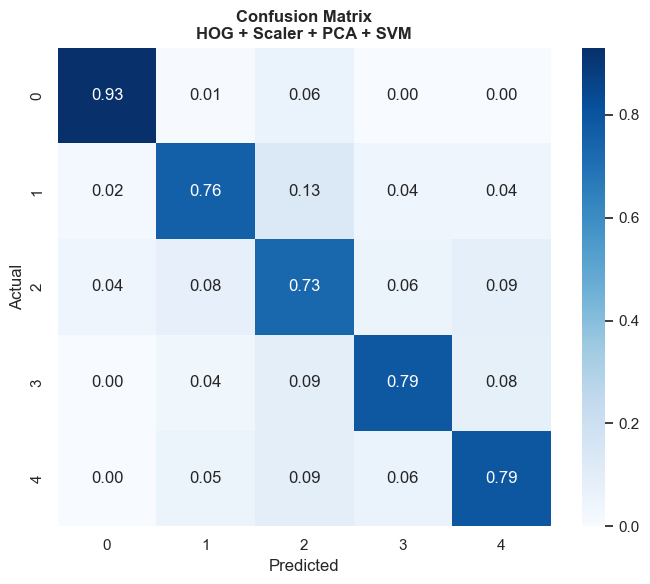

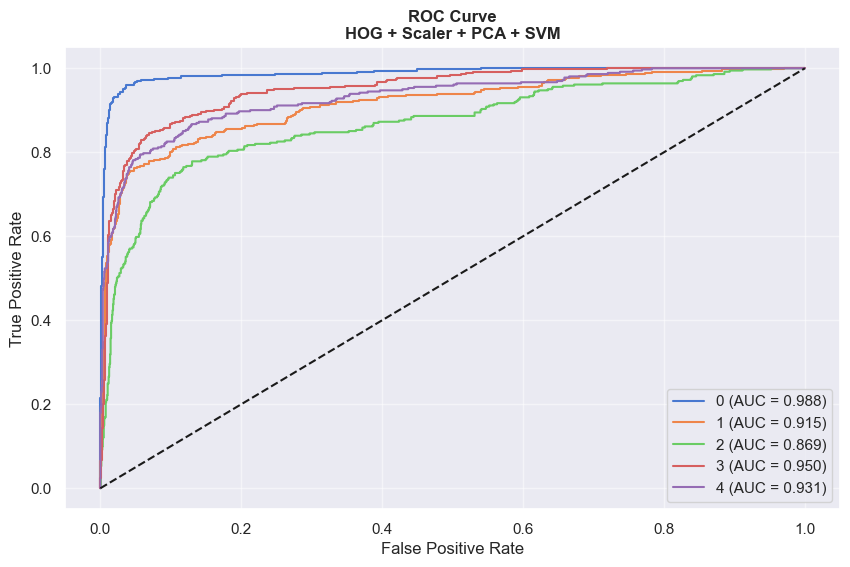

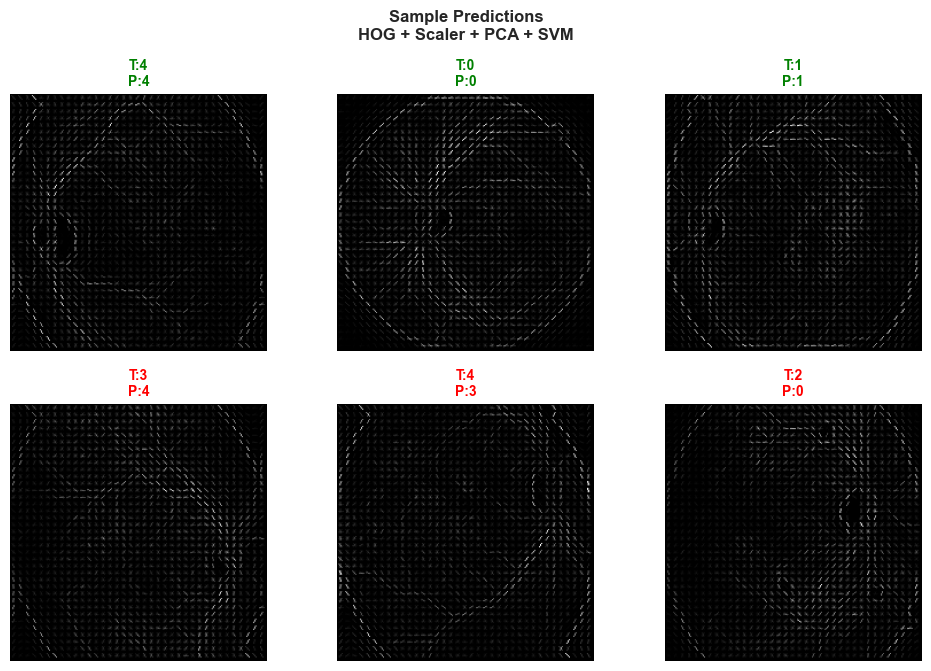

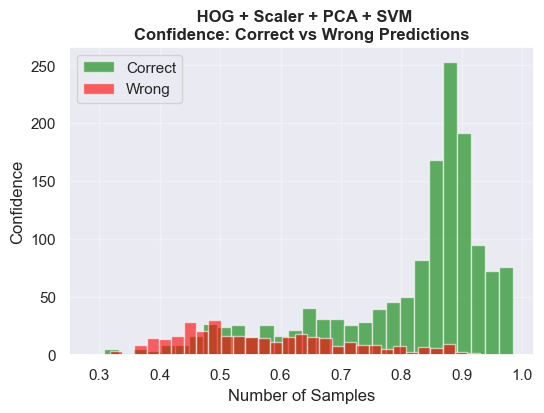

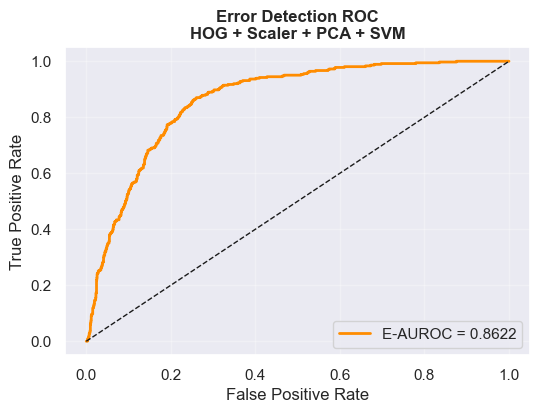


===== METRICS =====

|Classification Report|
               precision    recall  f1-score   support

           0     0.9256    0.9307    0.9282       361
           1     0.8125    0.7562    0.7834       361
           2     0.6608    0.7341    0.6955       361
           3     0.8280    0.7867    0.8068       361
           4     0.7873    0.7895    0.7884       361

    accuracy                         0.7994      1805
   macro avg     0.8028    0.7994    0.8005      1805
weighted avg     0.8028    0.7994    0.8005      1805


| Model: HOG + Scaler + PCA + SVM
| QWK: 0.8513
| Accuracy: 0.7994
| Precision (Macro): 0.8028
| Recall (Macro): 0.7994
| F1 Score (Macro): 0.8005
| AUC (Macro): 0.9307
| AURC: 0.0543
| E-AUROC: 0.8622
| Mean Confidence: 0.7606
| Conf Separation: 0.2300

--- Results updated and saved to C:\Users\eliza\Portfolio\blindness-detection\hog_svm_data\hog_results.csv ---


In [24]:
metrics_svm = evaluate_model(
    X_val_pca, y_val, 
    "HOG + Scaler + PCA + SVM", 
    EXPORT_DIR / "svm_ovo_model1.pkl", 
    EXPORT_DIR / "svm_ovr_model1.pkl", 
    hog_imgs=X_val_hog_imgs
)

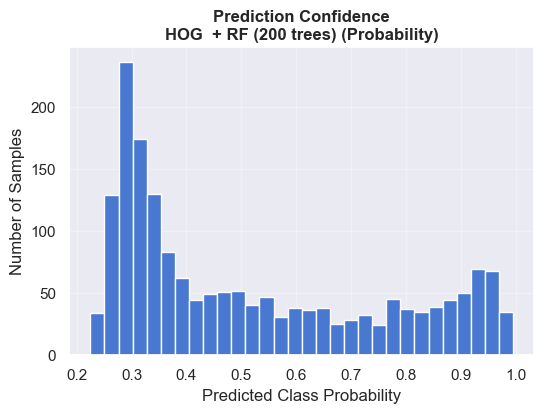

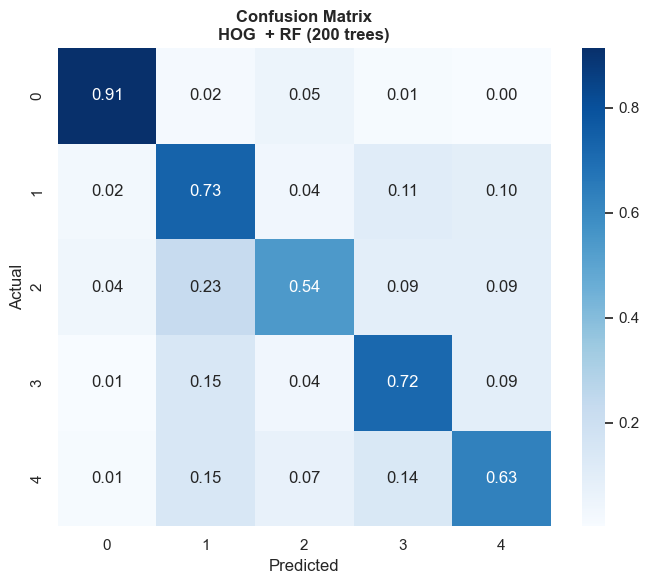

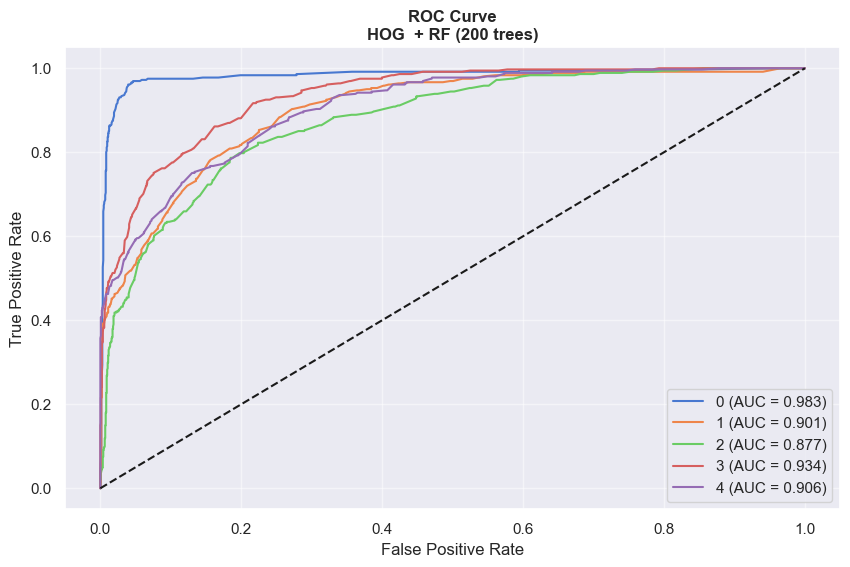

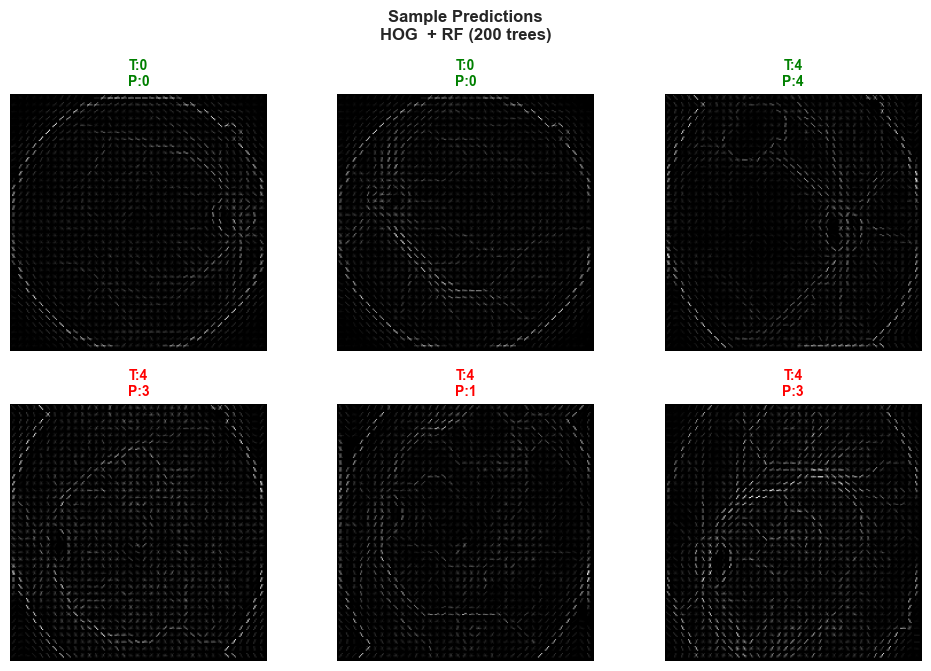

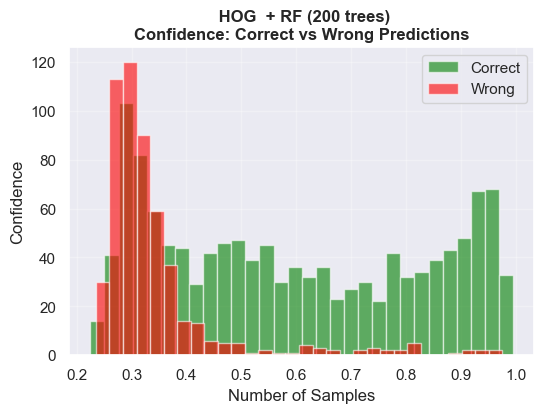

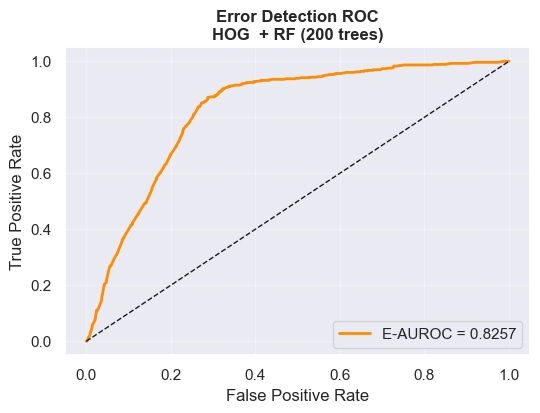


===== METRICS =====

|Classification Report|
               precision    recall  f1-score   support

           0     0.9192    0.9141    0.9167       361
           1     0.5748    0.7341    0.6448       361
           2     0.7341    0.5429    0.6242       361
           3     0.6710    0.7175    0.6934       361
           4     0.6867    0.6316    0.6580       361

    accuracy                         0.7080      1805
   macro avg     0.7172    0.7080    0.7074      1805
weighted avg     0.7172    0.7080    0.7074      1805


| Model: HOG  + RF (200 trees)
| QWK: 0.7356
| Accuracy: 0.7080
| Precision (Macro): 0.7172
| Recall (Macro): 0.7080
| F1 Score (Macro): 0.7074
| AUC (Macro): 0.9202
| AURC: 0.1100
| E-AUROC: 0.8257
| Mean Confidence: 0.5205
| Conf Separation: 0.2511

--- Results updated and saved to C:\Users\eliza\Portfolio\blindness-detection\hog_svm_data\hog_results.csv ---


In [13]:
metrics_rf = evaluate_model(
    X_val, y_val, 
    "HOG  + RF (200 trees)", 
    model_path1=EXPORT_DIR / "rf_raw_model1.pkl", 
    hog_imgs=X_val_hog_imgs
)

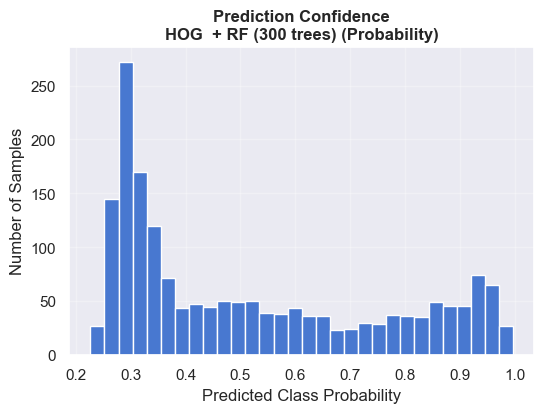

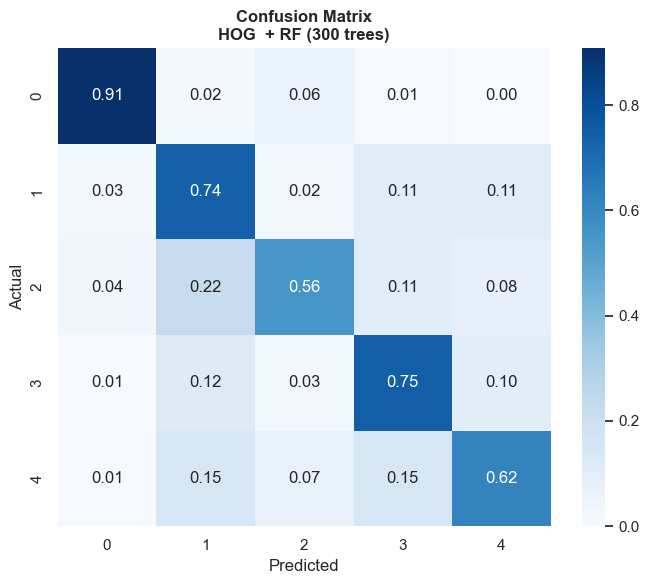

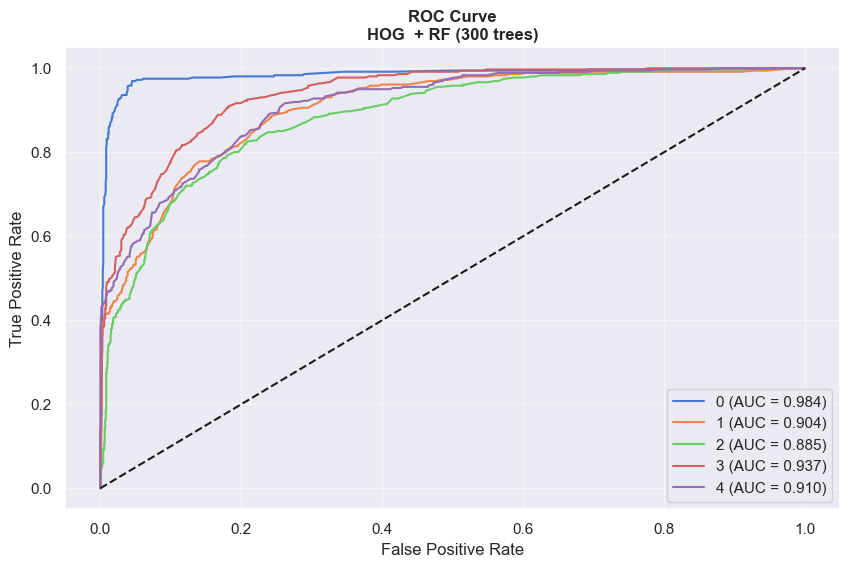

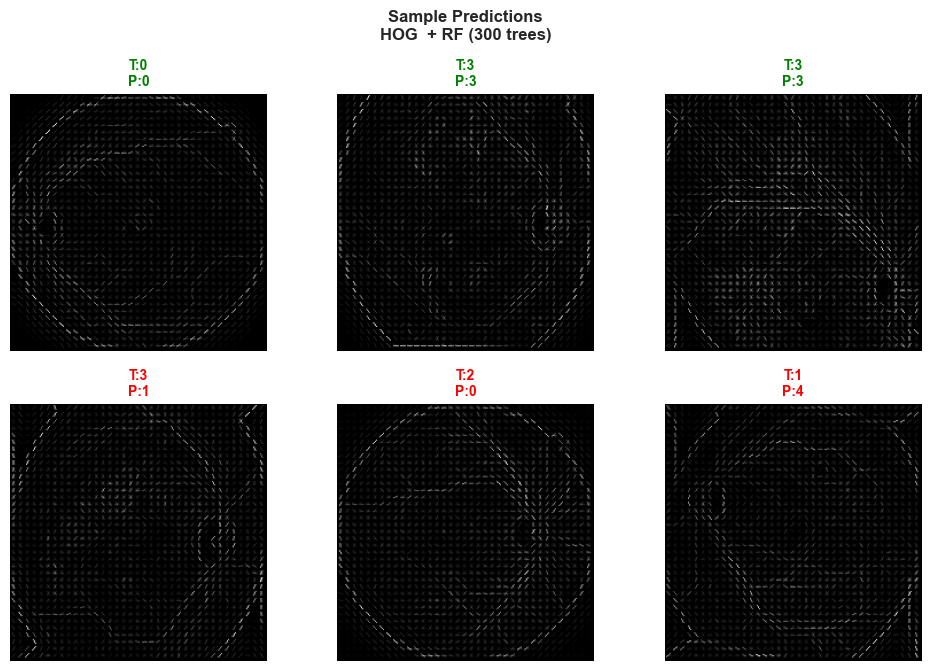

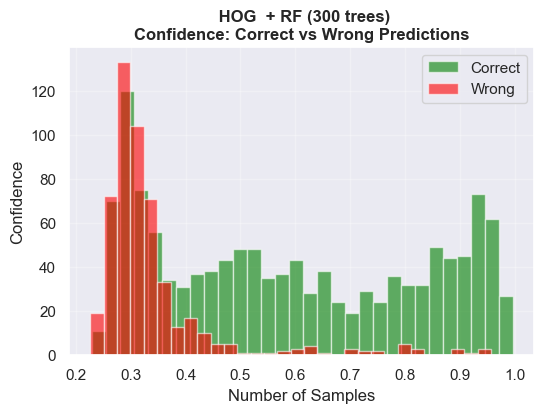

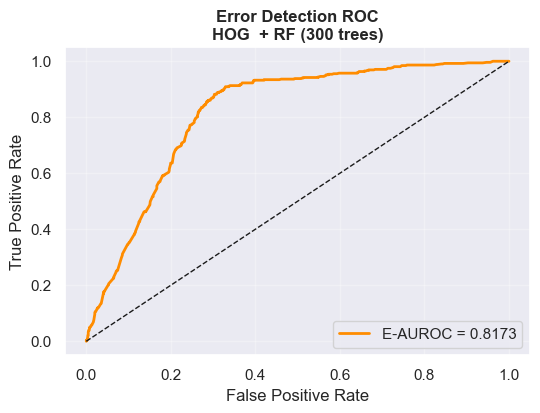


===== METRICS =====

|Classification Report|
               precision    recall  f1-score   support

           0     0.9188    0.9086    0.9136       361
           1     0.5885    0.7368    0.6544       361
           2     0.7556    0.5568    0.6411       361
           3     0.6658    0.7452    0.7033       361
           4     0.6871    0.6205    0.6521       361

    accuracy                         0.7136      1805
   macro avg     0.7232    0.7136    0.7129      1805
weighted avg     0.7232    0.7136    0.7129      1805


| Model: HOG  + RF (300 trees)
| QWK: 0.7394
| Accuracy: 0.7136
| Precision (Macro): 0.7232
| Recall (Macro): 0.7136
| F1 Score (Macro): 0.7129
| AUC (Macro): 0.9241
| AURC: 0.1086
| E-AUROC: 0.8173
| Mean Confidence: 0.5192
| Conf Separation: 0.2488

--- Results updated and saved to C:\Users\eliza\Portfolio\blindness-detection\hog_svm_data\hog_results.csv ---


In [14]:
metrics_rf = evaluate_model(
    X_val, y_val, 
    "HOG  + RF (300 trees)", 
    model_path1=EXPORT_DIR / "rf_raw_model2.pkl", 
    hog_imgs=X_val_hog_imgs
)

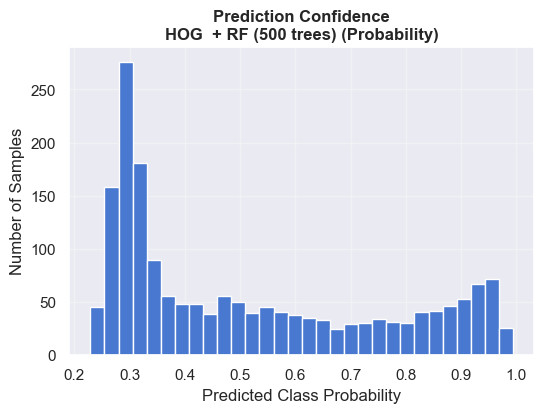

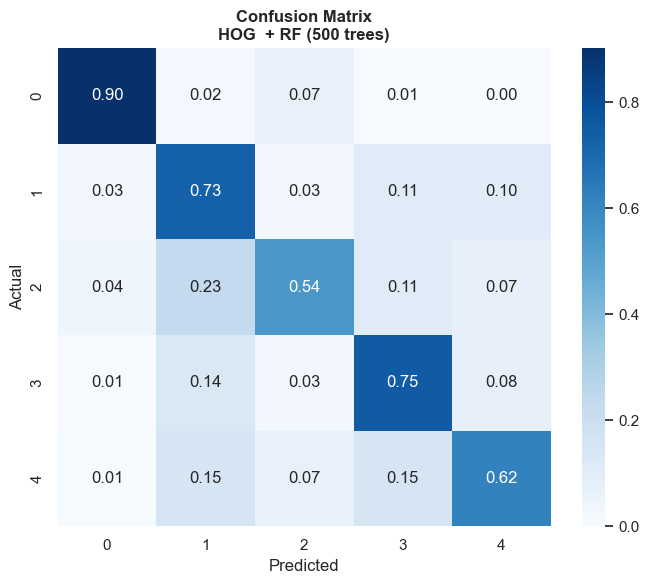

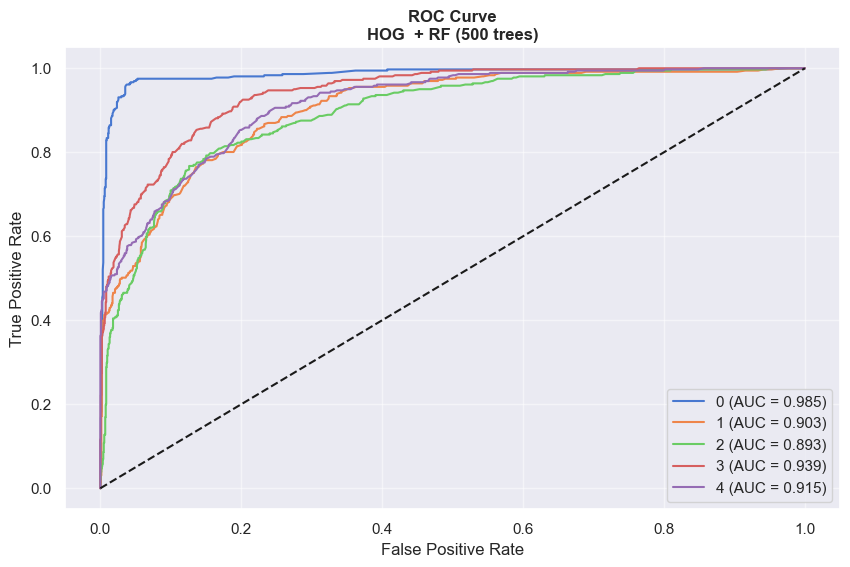

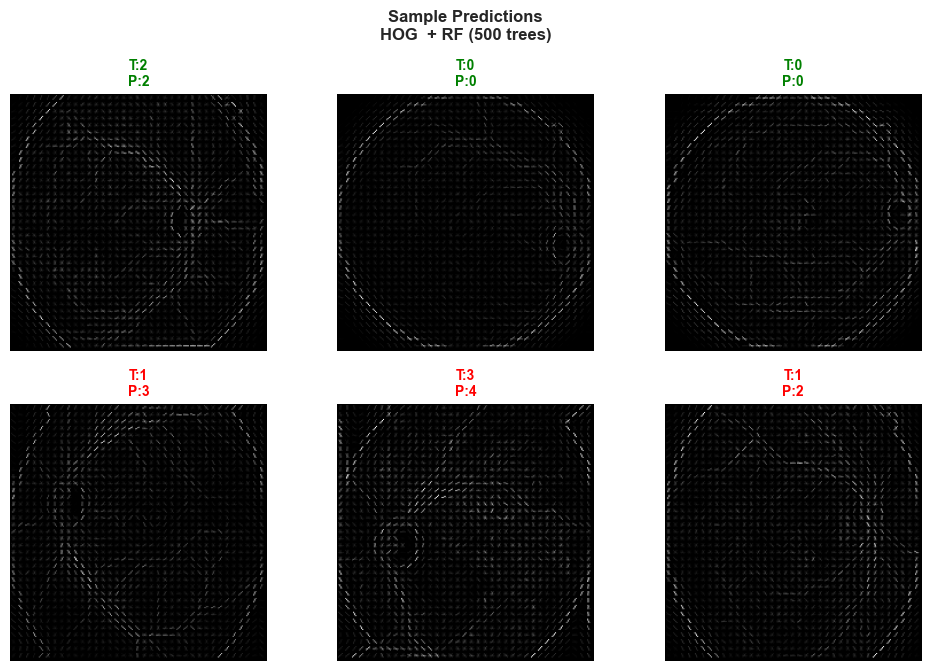

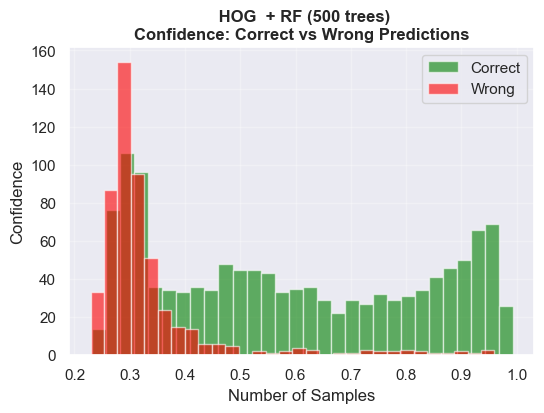

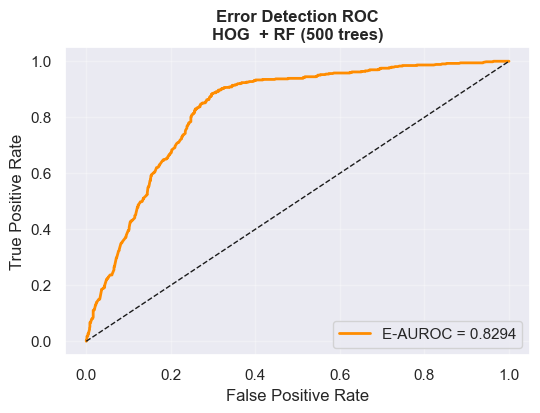


===== METRICS =====

|Classification Report|
               precision    recall  f1-score   support

           0     0.9157    0.9030    0.9093       361
           1     0.5752    0.7313    0.6439       361
           2     0.7368    0.5429    0.6252       361
           3     0.6650    0.7535    0.7065       361
           4     0.7079    0.6177    0.6598       361

    accuracy                         0.7097      1805
   macro avg     0.7201    0.7097    0.7089      1805
weighted avg     0.7201    0.7097    0.7089      1805


| Model: HOG  + RF (500 trees)
| QWK: 0.7375
| Accuracy: 0.7097
| Precision (Macro): 0.7201
| Recall (Macro): 0.7097
| F1 Score (Macro): 0.7089
| AUC (Macro): 0.9269
| AURC: 0.1069
| E-AUROC: 0.8294
| Mean Confidence: 0.5170
| Conf Separation: 0.2547

--- Results updated and saved to C:\Users\eliza\Portfolio\blindness-detection\hog_svm_data\hog_results.csv ---


In [16]:
metrics_rf = evaluate_model(
    X_val, y_val, 
    "HOG  + RF (500 trees)", 
    model_path1=EXPORT_DIR / "rf_raw_mode3.pkl", 
    hog_imgs=X_val_hog_imgs
)

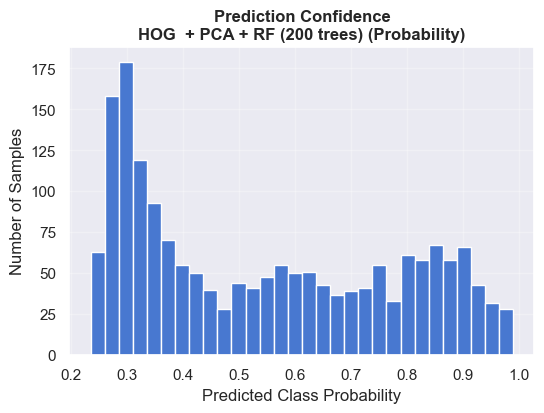

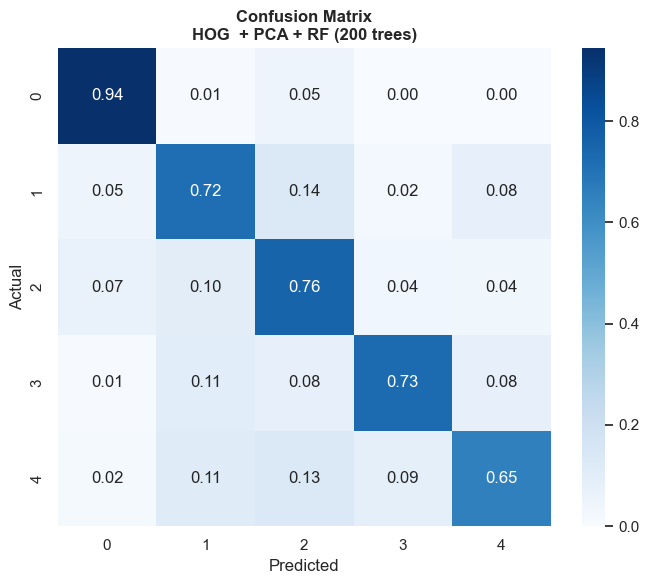

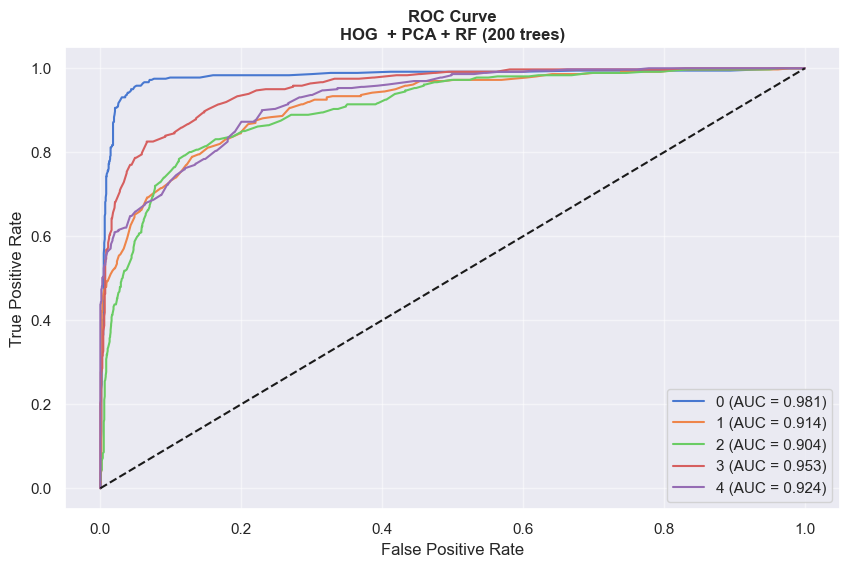

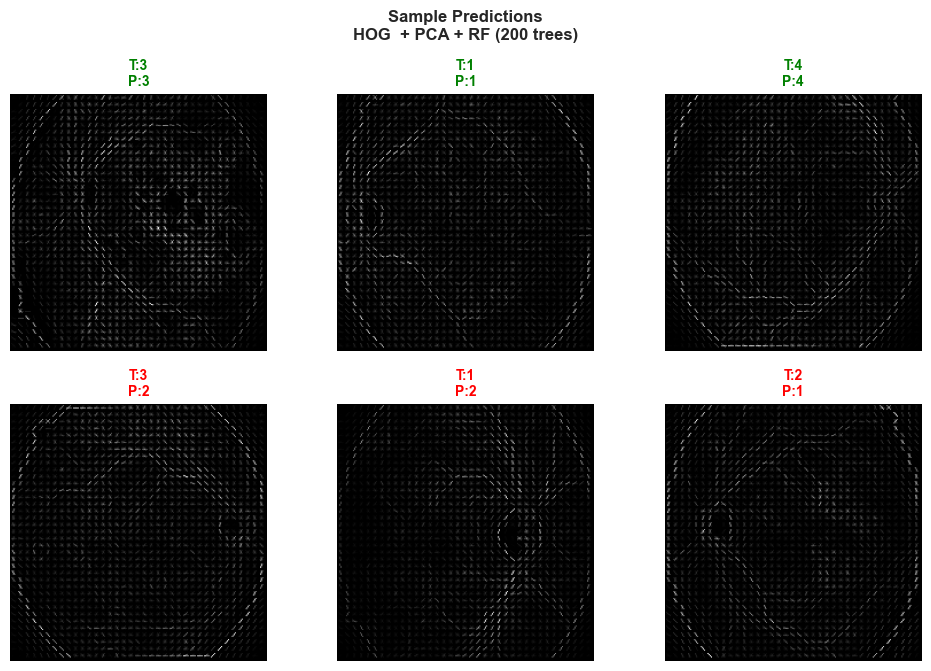

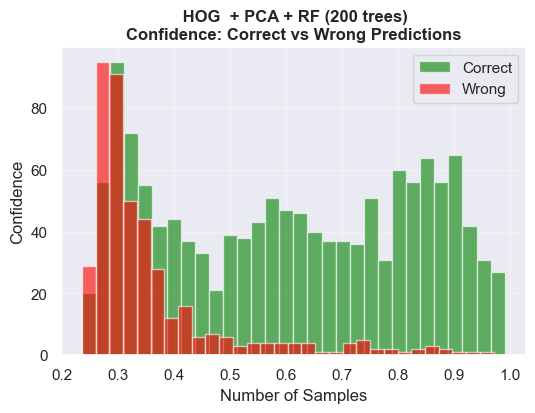

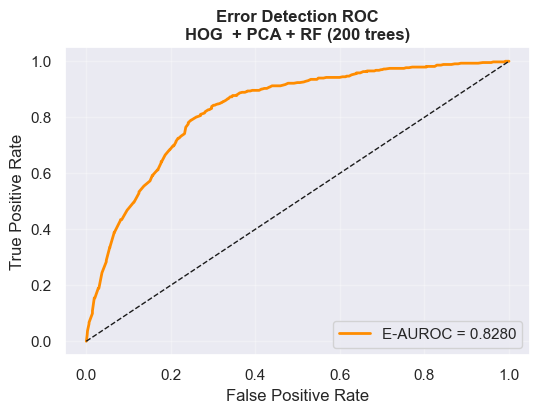


===== METRICS =====

|Classification Report|
               precision    recall  f1-score   support

           0     0.8721    0.9446    0.9069       361
           1     0.6888    0.7175    0.7028       361
           2     0.6547    0.7562    0.7018       361
           3     0.8376    0.7285    0.7793       361
           4     0.7687    0.6537    0.7066       361

    accuracy                         0.7601      1805
   macro avg     0.7644    0.7601    0.7595      1805
weighted avg     0.7644    0.7601    0.7595      1805


| Model: HOG  + PCA + RF (200 trees)
| QWK: 0.7843
| Accuracy: 0.7601
| Precision (Macro): 0.7644
| Recall (Macro): 0.7601
| F1 Score (Macro): 0.7595
| AUC (Macro): 0.9353
| AURC: 0.0858
| E-AUROC: 0.8280
| Mean Confidence: 0.5463
| Conf Separation: 0.2467

--- Results updated and saved to C:\Users\eliza\Portfolio\blindness-detection\hog_svm_data\hog_results.csv ---


In [17]:
metrics_rf = evaluate_model(
    X_val_pca, y_val, 
    "HOG  + PCA + RF (200 trees)", 
    model_path1 = EXPORT_DIR / "rf_model1.pkl",
    hog_imgs = X_val_hog_imgs
)

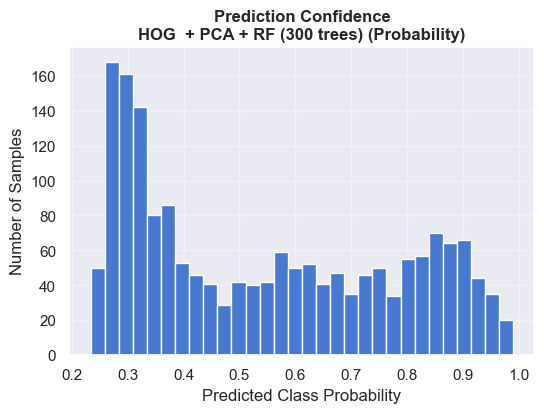

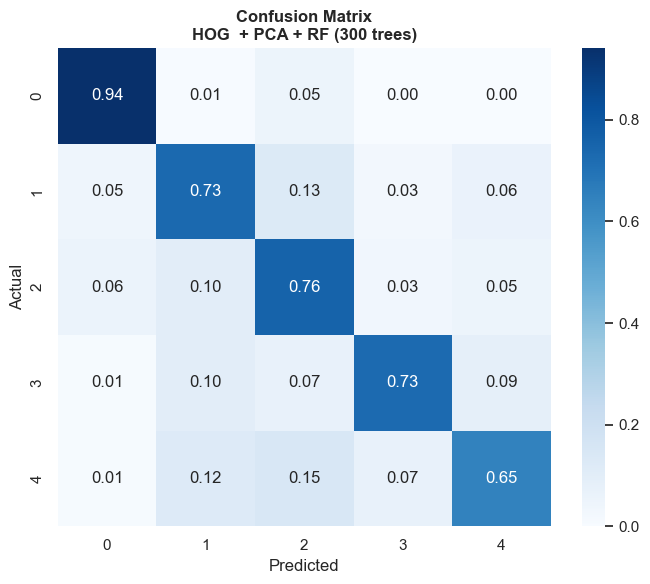

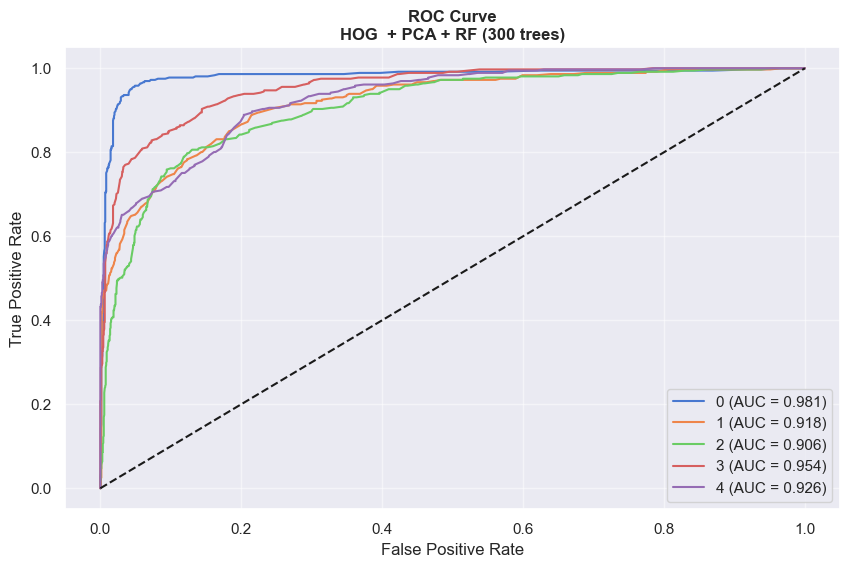

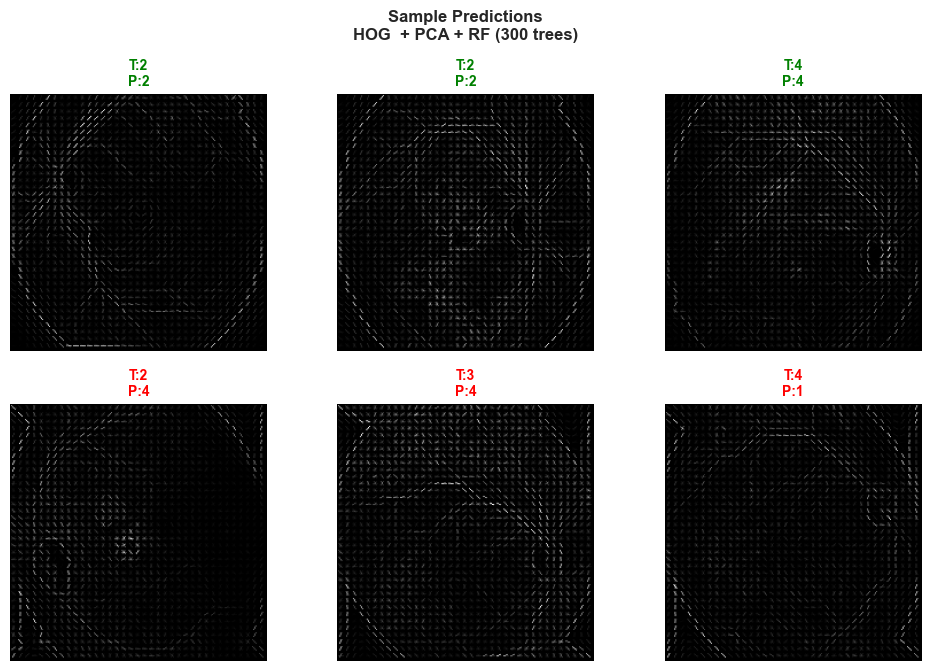

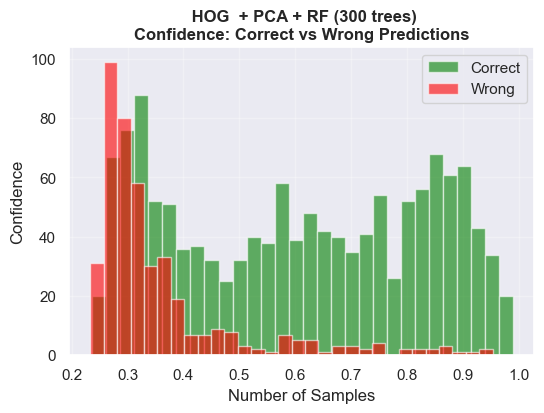

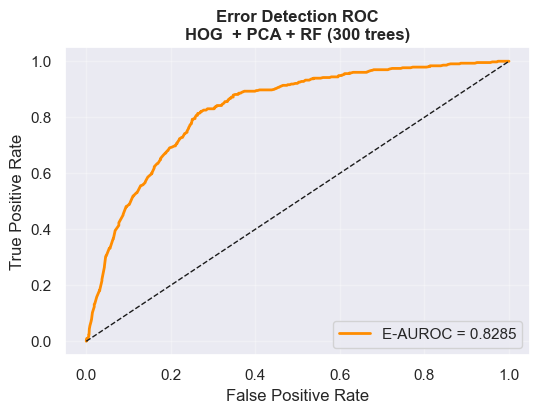


===== METRICS =====

|Classification Report|
               precision    recall  f1-score   support

           0     0.8854    0.9418    0.9128       361
           1     0.6883    0.7341    0.7105       361
           2     0.6531    0.7562    0.7009       361
           3     0.8462    0.7313    0.7845       361
           4     0.7614    0.6454    0.6987       361

    accuracy                         0.7618      1805
   macro avg     0.7669    0.7618    0.7615      1805
weighted avg     0.7669    0.7618    0.7615      1805


| Model: HOG  + PCA + RF (300 trees)
| QWK: 0.7845
| Accuracy: 0.7618
| Precision (Macro): 0.7669
| Recall (Macro): 0.7618
| F1 Score (Macro): 0.7615
| AUC (Macro): 0.9374
| AURC: 0.0844
| E-AUROC: 0.8285
| Mean Confidence: 0.5459
| Conf Separation: 0.2476

--- Results updated and saved to C:\Users\eliza\Portfolio\blindness-detection\hog_svm_data\hog_results.csv ---


In [18]:
metrics_rf = evaluate_model(
    X_val_pca, y_val, 
    "HOG  + PCA + RF (300 trees)", 
    model_path1 = EXPORT_DIR / "rf_model2.pkl",
    hog_imgs = X_val_hog_imgs
)

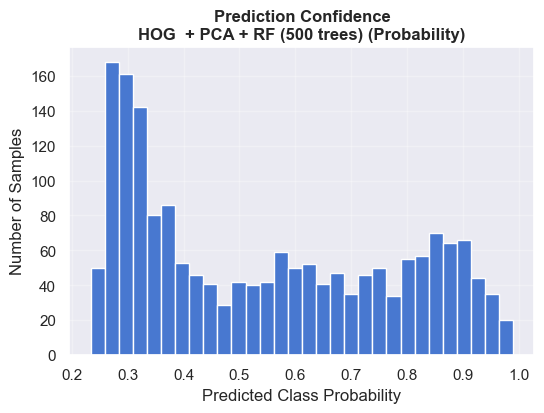

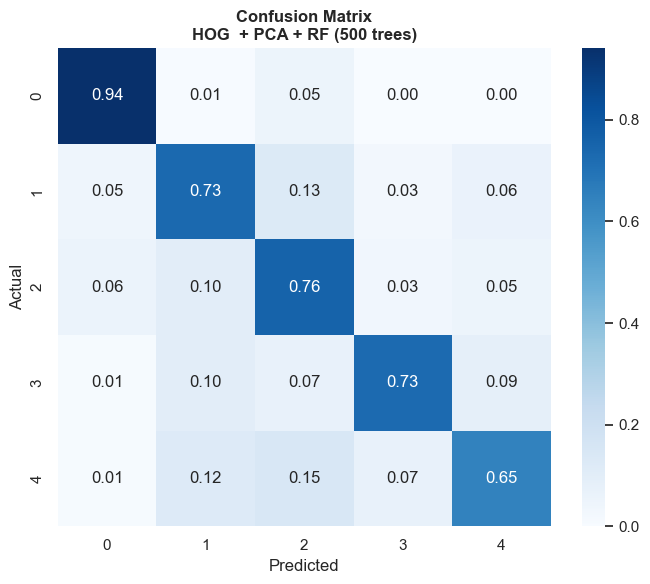

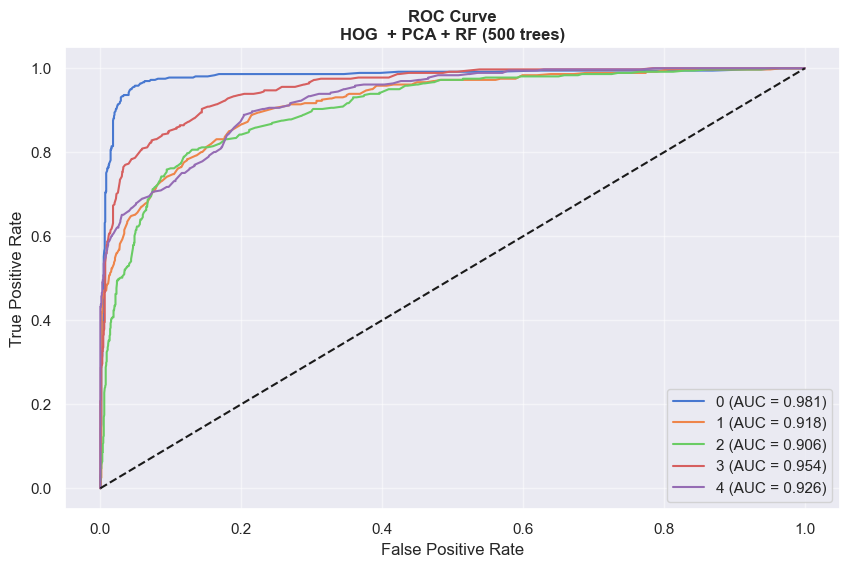

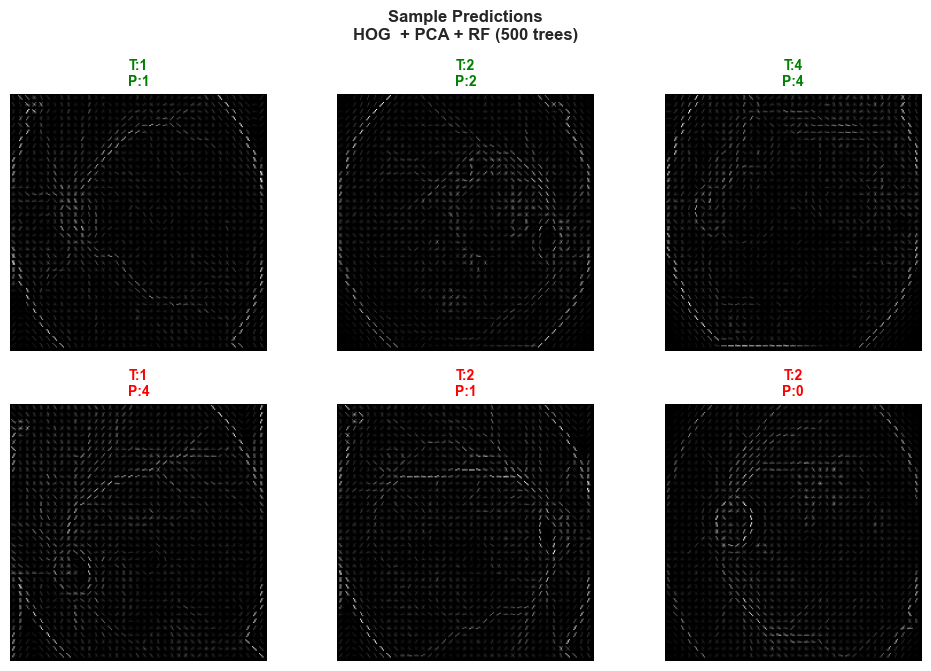

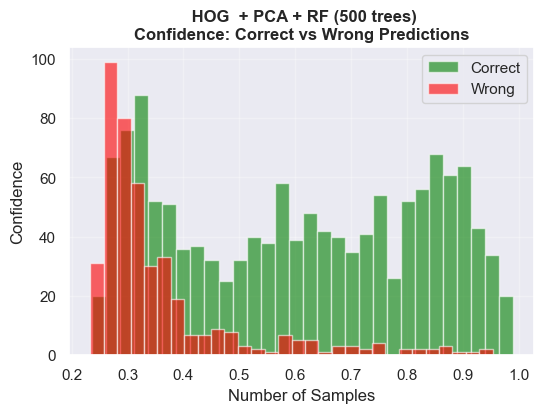

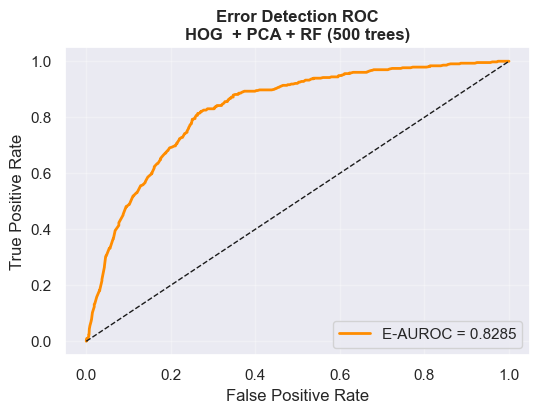


===== METRICS =====

|Classification Report|
               precision    recall  f1-score   support

           0     0.8854    0.9418    0.9128       361
           1     0.6883    0.7341    0.7105       361
           2     0.6531    0.7562    0.7009       361
           3     0.8462    0.7313    0.7845       361
           4     0.7614    0.6454    0.6987       361

    accuracy                         0.7618      1805
   macro avg     0.7669    0.7618    0.7615      1805
weighted avg     0.7669    0.7618    0.7615      1805


| Model: HOG  + PCA + RF (500 trees)
| QWK: 0.7845
| Accuracy: 0.7618
| Precision (Macro): 0.7669
| Recall (Macro): 0.7618
| F1 Score (Macro): 0.7615
| AUC (Macro): 0.9374
| AURC: 0.0844
| E-AUROC: 0.8285
| Mean Confidence: 0.5459
| Conf Separation: 0.2476

--- Results updated and saved to C:\Users\eliza\Portfolio\blindness-detection\hog_svm_data\hog_results.csv ---


In [19]:
metrics_rf = evaluate_model(
    X_val_pca, y_val, 
    "HOG  + PCA + RF (500 trees)", 
    model_path1 = EXPORT_DIR / "rf_model3.pkl",
    hog_imgs = X_val_hog_imgs
)

## Results

In [20]:
df = pd.read_csv(RESULTS_PATH)
df

,Model,QWK,Accuracy,Precision (Macro),Recall (Macro),F1 Score (Macro),AUC (Macro),AURC,E-AUROC,Mean Confidence,Conf Separation
0,HOG + Scaler + PCA + SVM (OvO),0.8513,0.7994,0.8028,0.7994,0.8005,0.9307,0.0543,0.8622,0.7606,0.2300
1,HOG + RF (200 trees),0.7356,0.7080,0.7172,0.7080,0.7074,0.9202,0.1100,0.8257,0.5205,0.2511
2,HOG + RF (300 trees),0.7394,0.7136,0.7232,0.7136,0.7129,0.9241,0.1086,0.8173,0.5192,0.2488
3,HOG + RF (500 trees),0.7375,0.7097,0.7201,0.7097,0.7089,0.9269,0.1069,0.8294,0.5170,0.2547
4,HOG + PCA + RF (200 trees),0.7843,0.7601,0.7644,0.7601,0.7595,0.9353,0.0858,0.8280,0.5463,0.2467
5,HOG + PCA + RF (300 trees),0.7845,0.7618,0.7669,0.7618,0.7615,0.9374,0.0844,0.8285,0.5459,0.2476
6,HOG + PCA + RF (500 trees),0.7845,0.7618,0.7669,0.7618,0.7615,0.9374,0.0844,0.8285,0.5459,0.2476


Although Random Forest is considered robust to high-dimensional features, in our experiments dimensionality reduction via PCA significantly improved performance when using HOG descriptors. This suggests that decorrelation and noise suppression are beneficial in texture-based medical image classification."

In [ ]:
# row_cnn = {
#     "Model": "CNN DenseNet121",
#     "QWK": 0.92,
#     "Accuracy": 0.85,	
#     "Precision (Macro)": 0.91,	
#     "Recall (Macro)": 0.73, 	
#     "F1 Score (Macro)": 0.85,
#     "AUC (Macro)": 0.97,
#     "AURC": 0.03,
#     "E-AUROC": 0.84,
#     "Mean Confidence": 0.75,
#     "Conf Separation": 0.23
# }
# df_cnn = pd.DataFrame([row_cnn])

In [22]:
df_full = pd.concat([df, df_cnn], ignore_index=True)
df_full

,Model,QWK,Accuracy,Precision (Macro),Recall (Macro),F1 Score (Macro),AUC (Macro),AURC,E-AUROC,Mean Confidence,Conf Separation
0,HOG + Scaler + PCA + SVM (OvO),0.8513,0.7994,0.8028,0.7994,0.8005,0.9307,0.0543,0.8622,0.7606,0.2300
1,HOG + RF (200 trees),0.7356,0.7080,0.7172,0.7080,0.7074,0.9202,0.1100,0.8257,0.5205,0.2511
2,HOG + RF (300 trees),0.7394,0.7136,0.7232,0.7136,0.7129,0.9241,0.1086,0.8173,0.5192,0.2488
3,HOG + RF (500 trees),0.7375,0.7097,0.7201,0.7097,0.7089,0.9269,0.1069,0.8294,0.5170,0.2547
4,HOG + PCA + RF (200 trees),0.7843,0.7601,0.7644,0.7601,0.7595,0.9353,0.0858,0.8280,0.5463,0.2467
5,HOG + PCA + RF (300 trees),0.7845,0.7618,0.7669,0.7618,0.7615,0.9374,0.0844,0.8285,0.5459,0.2476
6,HOG + PCA + RF (500 trees),0.7845,0.7618,0.7669,0.7618,0.7615,0.9374,0.0844,0.8285,0.5459,0.2476
7,CNN DenseNet121,0.9200,0.8500,0.9100,0.7300,0.8500,0.9700,0.0300,0.8400,0.7500,0.2300


In [23]:
df_full.to_csv(EXPORT_DIR / "hog_results_full.csv", index=False)